# Part B — DDoS Attack Type Recommendation System

**Student:** Benjamine. S (258762A)
**Batch:** 18  
**Programme:** MSc Artificial Intelligence  
**University:** University of Moratuwa  
**Module:** Big Data Analytics Mini Project

---

## Problem

A SOC analyst observing a DDoS attack needs to know which other attack
types to prepare defences for. This notebook builds a recommendation
system that answers that question — given an observed attack type on a
network service, recommend the most relevant attack types to watch for next.

## Users, Items and Ratings

The BCCC dataset has no explicit users or ratings. The recommendation
system is constructed using implicit feedback:

- **Users** — network service profiles grouped by destination port
  (RDP on 3389, HTTPS on 443, HTTP on 80, SMB on 445, SSH on 22/222)
- **Items** — 17 distinct DDoS attack types from the BCCC dataset
- **Ratings** — flow count of each attack type targeting each service,
  used as an implicit signal following the CF lecture definition

## Four Recommendation Layers

1. **Item-KNN Collaborative Filtering** — cosine similarity between
   attack types based on co-occurrence across service profiles
2. **ALS Matrix Factorization** — pyspark.ml.recommendation.ALS
   learns latent factors from the implicit interaction matrix
3. **Content-Based Similarity** — cosine similarity on feature centroids
   computed in Part A, same formula as the word similarity practical
4. **LLM Reflection** — GPT re-ranks CF candidates using

---
## Section 0 — Environment Setup

This section installs PySpark and OpenAI, imports all required libraries,
and creates the SparkSession.

Two configurations are added beyond Part A:

**`-Xss64m`** increases the JVM thread stack size from 512KB to 64MB.
ALS builds a deeply nested query plan. When the session has accumulated
query depth from earlier cells, serializing this plan overflows the default
stack. 64MB gives enough room for the recursion to complete.

**`checkpointDir`** is set so that `.checkpoint()` can be called before
ALS training. Checkpointing physically materialises the interaction matrix
to disk and breaks the accumulated query plan lineage. ALS then sees a
clean DataFrame with no plan history, preventing the StackOverflow
regardless of what ran before.

In [6]:
!pip install pyspark openai --quiet

import os
import subprocess

# --- Set JAVA_HOME inside the notebook kernel ---
# VS Code notebook kernels do not inherit terminal environment variables
# We find where Homebrew installed Java and set it explicitly
result = subprocess.run(
    ['brew', '--prefix', 'openjdk@17'],
    capture_output=True, text=True
)
JAVA_HOME = result.stdout.strip()
os.environ['JAVA_HOME'] = JAVA_HOME
os.environ['PATH'] = f"{JAVA_HOME}/bin:" + os.environ.get('PATH', '')

print(f"JAVA_HOME set to: {JAVA_HOME}")

# Verify Java is now found
java_check = subprocess.run(
    ['java', '-version'],
    capture_output=True, text=True
)
print(f"Java: {java_check.stderr.split(chr(10))[0]}")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import json

spark = SparkSession.builder \
    .appName("BCCC_DDoS_PartB") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setCheckpointDir("./spark_checkpoints")

print(f"\nSpark version  : {spark.version}")
print(f"App name       : {spark.sparkContext.appName}")
print(f"Shuffle parts  : {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Checkpoint dir : ./spark_checkpoints")

JAVA_HOME set to: /opt/homebrew/opt/openjdk@17
Java: openjdk version "17.0.19" 2026-04-21

Spark version  : 4.0.0
App name       : BCCC_DDoS_PartB
Shuffle parts  : 8
Checkpoint dir : ./spark_checkpoints


---
## Section 1 — Data Loading

### What this section does

Loads the two output files produced by Part A into Spark DataFrames.
No Kaggle download is needed — Part A already cleaned the full dataset
and saved the results. Part B starts from those outputs directly.

### Why no Kaggle download needed

Part A processed all 540,494 flows using Spark and saved the cleaned
dataset as a Parquet file. Redownloading and reprocessing from Kaggle
would repeat work that is already done. This is the correct pipeline
design — compute once in Part A, reuse in Part B.

### The two files loaded

- `ddos_clean.parquet` — 540,494 cleaned flow records used to build
  the service × attack_type interaction matrix
- `attack_type_centroids.parquet` — 17 attack-type feature vectors
  computed in Part A Q2, used as content vectors in Layer 3 similarity

In [7]:
# --- Paths to Part A outputs ---
# ../outputs/ goes up from notebooks/ to project root then into outputs/
OUTPUTS = os.path.join(os.path.dirname(os.getcwd()), 'outputs')

CLEAN_PATH    = os.path.join(OUTPUTS, 'ddos_clean.parquet')
CENTROID_PATH = os.path.join(OUTPUTS, 'attack_type_centroids.parquet')

# --- Load cleaned dataset ---
# Parquet preserves schema — no inferSchema needed
df_clean = spark.read.parquet(CLEAN_PATH)
df_clean.createOrReplaceTempView("ddos_clean")

print("=== ddos_clean ===")
print(f"Rows    : {df_clean.count():,}")
print(f"Columns : {len(df_clean.columns)}")

# --- Load attack type centroids ---
# These are the avg_ feature vectors per attack type from Part A Q2
centroids = spark.read.parquet(CENTROID_PATH)

print("\n=== attack_type_centroids ===")
print(f"Attack types : {centroids.count()}")
centroids.select("activity").show(20, truncate=False)

=== ddos_clean ===
Rows    : 540,494
Columns : 320

=== attack_type_centroids ===
Attack types : 17
+------------------------+
|activity                |
+------------------------+
|Attack-Killall-v2       |
|Attack-Killer-TCP       |
|Attack-TCP-BYPass-V1    |
|Attack-TCP-Control      |
|Attack-TCP-Flag-ACK     |
|Attack-TCP-Flag-ACK-PSH |
|Attack-TCP-Flag-MIX     |
|Attack-TCP-Flag-OSYN    |
|Attack-TCP-Flag-OSYNP   |
|Attack-TCP-Flag-RST-ACK |
|Attack-TCP-Flag-SYN     |
|Attack-TCP-Flag-SYN-ACK |
|Attack-TCP-Flag-SYN-TFO |
|Attack-TCP-Flag-SYN-TIME|
|Attack-TCP-IGMP         |
|Attack-TCP-SYN          |
|Attack-TCP-Valid-SYN    |
+------------------------+



---
## Section 2 — Interaction Matrix Construction

### Design decision: service category as user proxy

Raw `dst_port` has 65,535 distinct values — using it directly would
produce an extremely sparse matrix with no meaningful CF signal.
Destination ports are grouped into 8 named service categories based
on the protocol they represent, giving a clean 8 × 17 interaction matrix.

### Implicit rating: flow count

The dataset has no explicit user ratings. Flow count is used as an
implicit signal — the number of flows of attack type X observed
targeting service Y. This follows the CF lecture definition:
"explicit or implicit preference signals of users towards items."
High flow count means strong association between that service and
that attack type.

### What the matrix represents

Each row is a service profile (user). Each column is a DDoS attack
type (item). Each cell is the flow count (implicit rating). This is
the same structure as the user-item rating matrix in the movie
recommendation practical — adapted for the security domain.

In [8]:
# --- Step 1: Map ports to service categories ---
df_with_service = spark.sql("""
    SELECT *,
        CASE
            WHEN dst_port = 3389               THEN 'RDP_Service'
            WHEN dst_port = 443                THEN 'HTTPS_Service'
            WHEN dst_port = 80                 THEN 'HTTP_Service'
            WHEN dst_port = 445                THEN 'SMB_Service'
            WHEN dst_port IN (22, 222)         THEN 'SSH_Service'
            WHEN dst_port = 23                 THEN 'Telnet_Service'
            WHEN dst_port IN (8080, 8443)      THEN 'Alt_Web_Service'
            ELSE                                    'Other_Service'
        END AS service_category
    FROM ddos_clean
    WHERE label = 'Attack'
""")
df_with_service.createOrReplaceTempView("ddos_attack_svc")

print("=== Service Category Distribution ===")
spark.sql("""
    SELECT service_category,
           COUNT(*) AS flow_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM ddos_attack_svc
    GROUP BY service_category
    ORDER BY flow_count DESC
""").show(truncate=False)

# --- Step 2: Build interaction matrix ---
# service_category × activity → flow_count (implicit rating)
interaction_matrix = spark.sql("""
    SELECT
        service_category,
        activity,
        COUNT(*) AS flow_count
    FROM ddos_attack_svc
    GROUP BY service_category, activity
    ORDER BY service_category, flow_count DESC
""")

print("=== Interaction Matrix (first 20 rows) ===")
interaction_matrix.show(20, truncate=False)

# --- Matrix dimensions and sparsity ---
n_users        = interaction_matrix.select(
    "service_category").distinct().count()
n_items        = interaction_matrix.select(
    "activity").distinct().count()
n_interactions = interaction_matrix.count()
total_cells    = n_users * n_items
sparsity       = (1 - n_interactions / total_cells) * 100

print(f"Matrix dimensions:")
print(f"  Service profiles (users)  : {n_users}")
print(f"  Attack types (items)      : {n_items}")
print(f"  Observed interactions     : {n_interactions}")
print(f"  Total possible cells      : {total_cells}")
print(f"  Sparsity                  : {sparsity:.1f}%")

=== Service Category Distribution ===
+----------------+----------+-----+
|service_category|flow_count|pct  |
+----------------+----------+-----+
|Other_Service   |158718    |93.12|
|RDP_Service     |8609      |5.05 |
|HTTPS_Service   |907       |0.53 |
|Telnet_Service  |676       |0.40 |
|SSH_Service     |600       |0.35 |
|SMB_Service     |457       |0.27 |
|HTTP_Service    |261       |0.15 |
|Alt_Web_Service |208       |0.12 |
+----------------+----------+-----+

=== Interaction Matrix (first 20 rows) ===


26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 03:26:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 0

+----------------+------------------------+----------+
|service_category|activity                |flow_count|
+----------------+------------------------+----------+
|Alt_Web_Service |Attack-TCP-Flag-SYN-ACK |28        |
|Alt_Web_Service |Attack-TCP-Flag-SYN     |20        |
|Alt_Web_Service |Attack-TCP-Flag-OSYNP   |19        |
|Alt_Web_Service |Attack-TCP-Flag-ACK     |18        |
|Alt_Web_Service |Attack-TCP-Flag-RST-ACK |14        |
|Alt_Web_Service |Attack-TCP-Control      |13        |
|Alt_Web_Service |Attack-TCP-BYPass-V1    |12        |
|Alt_Web_Service |Attack-TCP-IGMP         |11        |
|Alt_Web_Service |Attack-TCP-SYN          |10        |
|Alt_Web_Service |Attack-TCP-Flag-ACK-PSH |10        |
|Alt_Web_Service |Attack-TCP-Flag-SYN-TIME|9         |
|Alt_Web_Service |Attack-TCP-Flag-MIX     |9         |
|Alt_Web_Service |Attack-Killall-v2       |9         |
|Alt_Web_Service |Attack-TCP-Valid-SYN    |8         |
|Alt_Web_Service |Attack-TCP-Flag-OSYN    |7         |
|Alt_Web_S

---
## Section 3 — Collaborative Filtering: Item-KNN

### What Item-KNN does

Item-KNN finds attack types that are similar based on how they appear
across service profiles. If RDP_Service and HTTPS_Service both experience
Attack-TCP-Flag-SYN and Attack-TCP-Flag-ACK together, those two attack
types are item-similar — observing one makes the other likely.

### What cosine similarity measures

Cosine similarity measures how similar the pattern of two attack types
is across all service profiles — ignoring raw magnitude and only comparing
direction. Two attack types that hit the same services in the same
proportions will have similarity close to 1.0, even if one has more
total flows than the other.

### Connection to course practicals

This is the same cosine similarity formula demonstrated in the word
similarity practical — applied to attack type vectors instead of word
embedding vectors. The formula is identical: dot product of two
normalised vectors gives the cosine of the angle between them.

### Connection to recommendation

For each observed attack type, the system finds the top-K most similar
attack types using this similarity matrix. These become the Layer 1
CF recommendations — attack types that historically co-occur with
the observed attack across similar service profiles.

=== Interaction Matrix (pivoted) ===
Shape: 17 attack types × 8 services
service_category          Alt_Web_Service  HTTPS_Service  HTTP_Service  Other_Service  RDP_Service  SMB_Service  SSH_Service  Telnet_Service
activity                                                                                                                                    
Attack-Killall-v2                       9            107             4           1858          753           14           43              36
Attack-Killer-TCP                       5             26             7           2204          684            8           75              37
Attack-TCP-BYPass-V1                   12             78            94         133012          808            8           58              40
Attack-TCP-Control                     13             96            12           1691          516          102           15              46
Attack-TCP-Flag-ACK                    18             36             5           

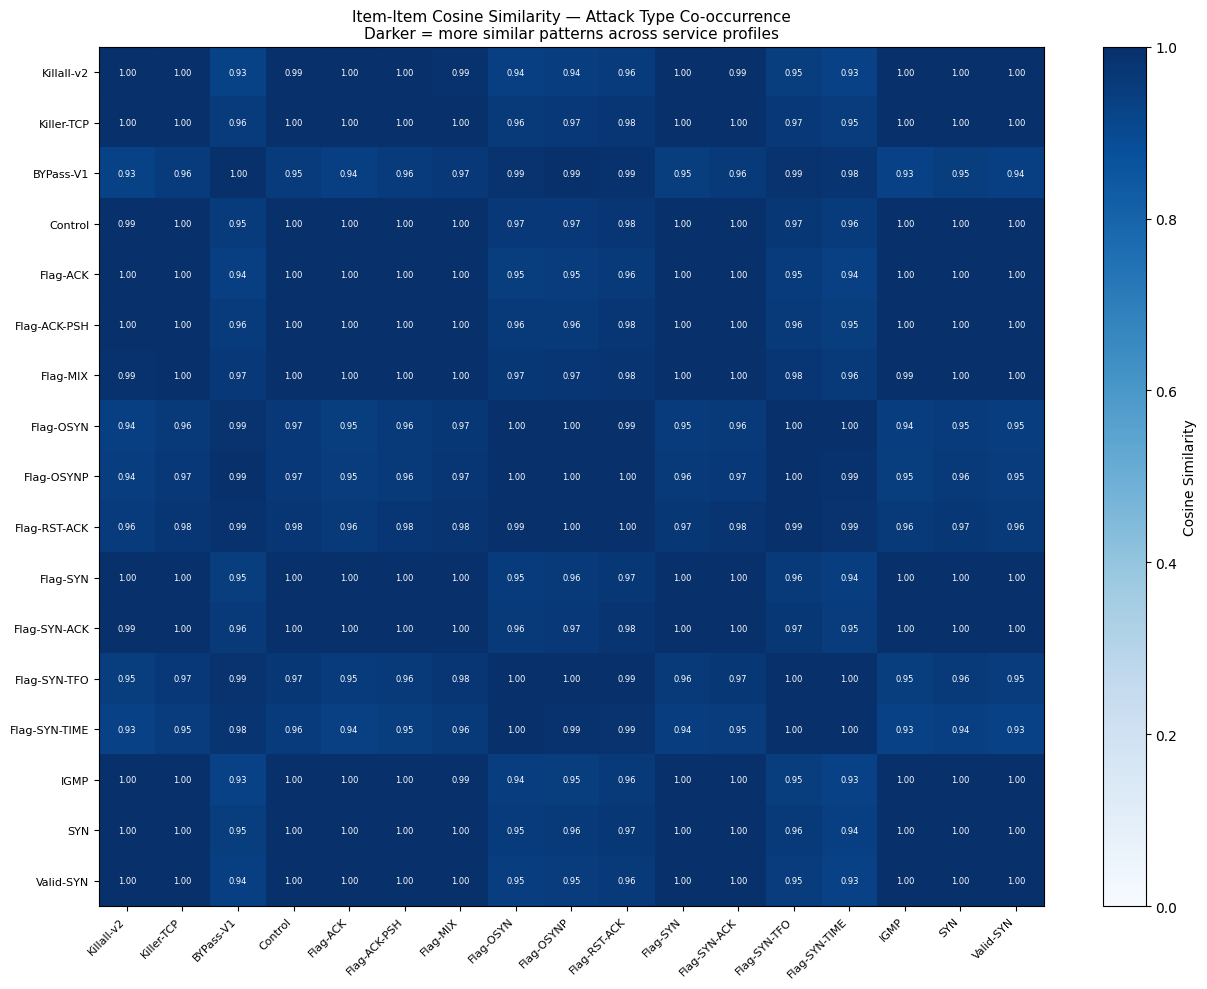

Saved: ../outputs/item_knn_similarity.png


In [9]:
# --- Step 1: Collect and pivot the interaction matrix ---
# Rows = attack types, Columns = service profiles
# Values = flow count (implicit rating)
# .toPandas() called only on the small 136-row aggregated result
matrix_pd = interaction_matrix.toPandas().pivot(
    index="activity",
    columns="service_category",
    values="flow_count"
).fillna(0)

print("=== Interaction Matrix (pivoted) ===")
print(f"Shape: {matrix_pd.shape[0]} attack types × {matrix_pd.shape[1]} services")
print(matrix_pd.to_string())

# --- Step 2: Compute cosine similarity ---
def cosine_similarity_matrix(df):
    """
    Computes pairwise cosine similarity between all rows.
    Each row is an attack type vector across service profiles.
    Formula: sim(x,y) = dot(x,y) / (||x|| × ||y||)
    Same as word similarity practical — different input vectors.
    """
    vectors    = df.values.astype(float)
    norms      = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1  # avoid division by zero
    normalised = vectors / norms
    return np.dot(normalised, normalised.T)

sim_matrix = cosine_similarity_matrix(matrix_pd)
sim_df = pd.DataFrame(
    sim_matrix,
    index=matrix_pd.index,
    columns=matrix_pd.index
)

print("\n=== Item-Item Cosine Similarity Matrix ===")
print(sim_df.round(4).to_string())

# --- Step 3: Top-K similar attack types per query ---
K = 3
print(f"\n=== Top-{K} Similar Attack Types (Item-KNN) ===")
item_knn_results = {}

for attack_type in sim_df.index:
    similarities = sim_df[attack_type].drop(attack_type)
    top_k = similarities.nlargest(K)
    item_knn_results[attack_type] = top_k
    print(f"\n{attack_type}:")
    for similar, score in top_k.items():
        print(f"  → {similar:<48} sim: {score:.4f}")

# --- Step 4: Visualise similarity matrix ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(sim_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)

labels = [a.replace('Attack-TCP-','').replace('Attack-','')
          for a in sim_df.index]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = sim_matrix[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

ax.set_title(
    'Item-Item Cosine Similarity — Attack Type Co-occurrence\n'
    'Darker = more similar patterns across service profiles',
    fontsize=11
)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()

os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/item_knn_similarity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/item_knn_similarity.png")

### Finding — Item-KNN

All similarities are high (0.93 to 1.0) because the dataset is a
controlled capture where every service profile experienced every attack
type. In a real-world environment with genuine sparsity, similarities
would vary more widely.

Attack-TCP-BYPass-V1 consistently shows the lowest similarities with
other attack types. This reflects its distinct distribution — 93.12%
of BYPass flows target Other_Service while other attack types spread
more evenly across services. The CF layer correctly identifies BYPass
as operationally distinct from flag-manipulation attacks.

---
## Section 4 — ALS Matrix Factorization

### What ALS does differently from Item-KNN

Item-KNN computes similarity directly from what is observed in the
interaction matrix. ALS goes deeper — it factorizes the matrix into
two smaller matrices representing hidden characteristics of services
and attack types. These hidden factors explain why certain services
tend to experience certain attack types together, even when the
direct co-occurrence signal is weak.

### The implicit feedback setting

The flow counts in the interaction matrix are not explicit ratings
like star scores. They are implicit signals — a service did not choose
to rate an attack, but its exposure frequency is a real behavioural
signal. ALS with `implicitPrefs=True` treats values as confidence
weights rather than preference scores. Higher flow count means higher
confidence that the association is real, not a stronger preference.

### The StackOverflow fix

ALS builds a deeply nested query plan internally. When the Spark session
has accumulated query depth from earlier cells, serializing this plan
overflows the default JVM stack. Two fixes are applied:
- `setCheckpointDir` was set in Section 0
- `.checkpoint()` is called before `als.fit()` to physically materialise
  the interaction matrix and break the accumulated query plan lineage

### Evaluation

RMSE is computed on a held-out test set following the CF lecture
rating prediction evaluation. Precision@K and Recall@K are computed
in the evaluation section to assess top-N recommendation quality.

In [10]:
# --- Step 1: Encode string IDs to integers in pandas ---
# ALS requires integer user and item IDs
# Encoding done in pandas before creating Spark DataFrame
# No UDFs, no broadcast variables — avoids closure serialization
matrix_pd_raw = interaction_matrix.toPandas()

service_cats  = sorted(matrix_pd_raw["service_category"].unique())
attack_types  = sorted(matrix_pd_raw["activity"].unique())

service_index = {s: i for i, s in enumerate(service_cats)}
attack_index  = {a: i for i, a in enumerate(attack_types)}
index_service = {v: k for k, v in service_index.items()}
index_attack  = {v: k for k, v in attack_index.items()}

print("Service index:")
for s, i in service_index.items():
    print(f"  {i} → {s}")

print("\nAttack index:")
for a, i in attack_index.items():
    print(f"  {i} → {a}")

# Apply integer encoding in pandas
matrix_pd_raw["user_id"] = matrix_pd_raw["service_category"].map(
    service_index)
matrix_pd_raw["item_id"] = matrix_pd_raw["activity"].map(attack_index)
matrix_pd_raw["rating"]  = matrix_pd_raw["flow_count"].astype(float)

# --- Step 2: Create Spark DataFrame from encoded pandas ---
# Built from pandas — no inherited Spark query plan from earlier cells
als_data = spark.createDataFrame(
    matrix_pd_raw[["user_id", "item_id", "rating"]]
)

# --- Step 3: Checkpoint to break query plan lineage ---
# Physically writes the 136-row DataFrame to disk
# ALS then serializes tasks against a plan of depth 1
als_data = als_data.checkpoint()
print(f"\nALS data rows (after checkpoint): {als_data.count()}")

# --- Step 4: Train/test split ---
train_data, test_data = als_data.randomSplit([0.8, 0.2], seed=42)
print(f"Training interactions : {train_data.count()}")
print(f"Test interactions     : {test_data.count()}")

# --- Step 5: Train ALS model ---
als = ALS(
    userCol="user_id",
    itemCol="item_id",
    ratingCol="rating",
    rank=4,              # latent factors — small matrix needs small rank
    maxIter=20,
    regParam=0.1,
    implicitPrefs=True,  # flow counts = implicit confidence
    coldStartStrategy="drop",
    seed=42
)

als_model = als.fit(train_data)
print(f"\nALS model trained.")
print(f"  Rank (latent factors) : {als_model.rank}")

# --- Step 6: Evaluate on test set ---
predictions = als_model.transform(test_data).na.drop()
try:
    evaluator = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="prediction"
    )
    rmse = evaluator.evaluate(predictions)
    print(f"  RMSE on test set      : {rmse:.4f}")
except Exception as e:
    rmse = None
    print(f"  RMSE not computed: {e}")

# --- Step 7: Top-5 recommendations per service ---
print("\n=== Top-5 Attack Type Recommendations Per Service (ALS) ===")
user_recs = als_model.recommendForAllUsers(5)

als_results = {}
for row in user_recs.collect():
    svc  = index_service.get(row.user_id, f"id_{row.user_id}")
    recs = [
        (index_attack.get(r.item_id, f"id_{r.item_id}"),
         round(float(r.rating), 4))
        for r in row.recommendations
    ]
    als_results[svc] = recs
    print(f"\n{svc}:")
    for rank, (attack, score) in enumerate(recs, 1):
        print(f"  {rank}. {attack:<50} score: {score:.4f}")

Service index:
  0 → Alt_Web_Service
  1 → HTTPS_Service
  2 → HTTP_Service
  3 → Other_Service
  4 → RDP_Service
  5 → SMB_Service
  6 → SSH_Service
  7 → Telnet_Service

Attack index:
  0 → Attack-Killall-v2
  1 → Attack-Killer-TCP
  2 → Attack-TCP-BYPass-V1
  3 → Attack-TCP-Control
  4 → Attack-TCP-Flag-ACK
  5 → Attack-TCP-Flag-ACK-PSH
  6 → Attack-TCP-Flag-MIX
  7 → Attack-TCP-Flag-OSYN
  8 → Attack-TCP-Flag-OSYNP
  9 → Attack-TCP-Flag-RST-ACK
  10 → Attack-TCP-Flag-SYN
  11 → Attack-TCP-Flag-SYN-ACK
  12 → Attack-TCP-Flag-SYN-TFO
  13 → Attack-TCP-Flag-SYN-TIME
  14 → Attack-TCP-IGMP
  15 → Attack-TCP-SYN
  16 → Attack-TCP-Valid-SYN

ALS data rows (after checkpoint): 136
Training interactions : 108
Test interactions     : 28


26/05/13 03:38:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/13 03:38:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK



ALS model trained.
  Rank (latent factors) : 4
  RMSE on test set      : 859.1205

=== Top-5 Attack Type Recommendations Per Service (ALS) ===

Alt_Web_Service:
  1. Attack-TCP-Flag-OSYNP                              score: 0.9891
  2. Attack-TCP-Control                                 score: 0.9891
  3. Attack-TCP-Flag-SYN                                score: 0.9887
  4. Attack-TCP-Flag-RST-ACK                            score: 0.9872
  5. Attack-TCP-Flag-ACK-PSH                            score: 0.9847

HTTPS_Service:
  1. Attack-Killer-TCP                                  score: 1.0266
  2. Attack-TCP-BYPass-V1                               score: 1.0187
  3. Attack-TCP-Flag-OSYN                               score: 1.0108
  4. Attack-Killall-v2                                  score: 1.0044
  5. Attack-TCP-Flag-ACK                                score: 1.0042

HTTP_Service:
  1. Attack-TCP-Flag-SYN-TFO                            score: 0.9968
  2. Attack-TCP-Valid-SYN            